Formel / Формула: R = 0.0146 × E^1.0169
Exponent b = 1.017


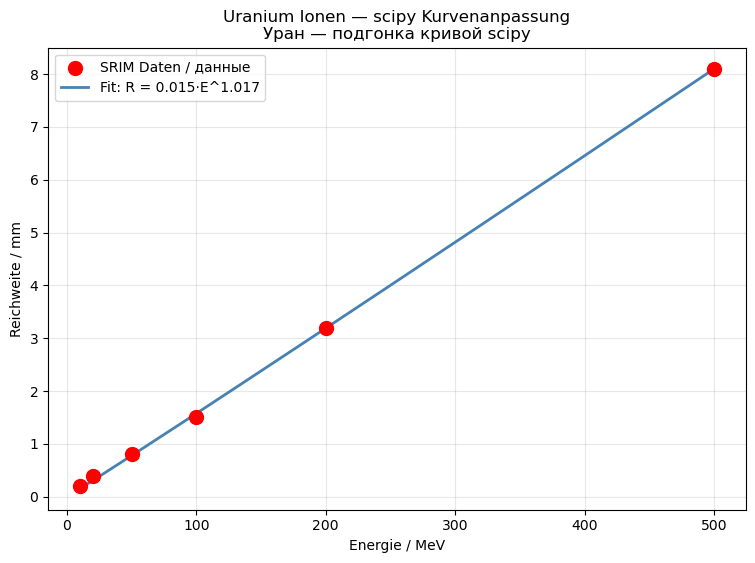

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Uranium Daten — wie in SRIM
# Уран — данные как в SRIM
energie = np.array([10, 20, 50, 100, 200, 500])
reichweite = np.array([0.2, 0.4, 0.8, 1.5, 3.2, 8.1])

# Kurvenformel definieren / определяем формулу кривой
def power_law(E, a, b):
    return a * E**b

# Kurve anpassen / подгоняем кривую
params, _ = curve_fit(power_law, energie, reichweite)
a, b = params

print(f"Formel / Формула: R = {a:.4f} × E^{b:.4f}")
print(f"Exponent b = {b:.3f}")

# Graph / График
E_fit = np.linspace(10, 500, 300)
R_fit = power_law(E_fit, a, b)

plt.figure(figsize=(9, 6))
plt.scatter(energie, reichweite, 
            color='red', s=100, zorder=5,
            label='SRIM Daten / данные')
plt.plot(E_fit, R_fit, 
         color='steelblue', linewidth=2,
         label=f'Fit: R = {a:.3f}·E^{b:.3f}')
plt.xlabel('Energie / MeV')
plt.ylabel('Reichweite / mm')
plt.title('Uranium Ionen — scipy Kurvenanpassung\n'
          'Уран — подгонка кривой scipy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()